In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
pip install gensim # NLPのためのオープンソースライブラリ

In [3]:
pip install mecab-python3 # 日本語形態素分析のライブラリ（MeCabの他にJUMANなどもある）

     |████████████████████████████████| 488 kB 12.8 MB/s 


In [4]:
pip install unidic # 日本語文書を単語に分割し，形態論情報を付与するための電子化辞書

  Created wheel for unidic: filename=unidic-1.1.0-py3-none-any.whl size=7426 sha256=9783b4aaae09a9f7a2be1f2c2abd91afdea4a2acd4fe647a4607c3c1cecc698f
  Stored in directory: /root/.cache/pip/wheels/ce/4d/f1/170bb74b559ca338113c0315c9805e16dfd0a12411ec6b1122
Successfully built unidic


In [5]:
!pip install optuna

     |████████████████████████████████| 308 kB 12.3 MB/s 
     |████████████████████████████████| 209 kB 52.5 MB/s 
     |████████████████████████████████| 80 kB 9.8 MB/s 
     |████████████████████████████████| 75 kB 4.7 MB/s 
     |████████████████████████████████| 112 kB 56.4 MB/s 
     |████████████████████████████████| 49 kB 6.5 MB/s 
     |████████████████████████████████| 149 kB 53.4 MB/s 
  Created wheel for pyperclip: filename=pyperclip-1.8.2-py3-none-any.whl size=11136 sha256=9d4fe9fa325100e77ca58541cada5c52c85468608f6134889d354e79ac15e7ee
  Stored in directory: /root/.cache/pip/wheels/9f/18/84/8f69f8b08169c7bae2dde6bd7daf0c19fca8c8e500ee620a28
Successfully built pyperclip


In [6]:
!python -m unidic download

download url: https://cotonoha-dic.s3-ap-northeast-1.amazonaws.com/unidic-3.1.0.zip
Dictionary version: 3.1.0+2021-08-31
unidic-3.1.0.zip: 100% 526M/526M [00:42<00:00, 12.5MB/s]
Finished download.
Downloaded UniDic v3.1.0+2021-08-31 to /usr/local/lib/python3.7/dist-packages/unidic/dicdir


In [7]:
# 形態素分析ライブラリーMeCab と 辞書(mecab-ipadic-NEologd)のインストール 
!apt-get -q -y install sudo file mecab libmecab-dev mecab-ipadic-utf8 git curl python-mecab > /dev/null
!git clone --depth 1 https://github.com/neologd/mecab-ipadic-neologd.git > /dev/null 
!echo yes | mecab-ipadic-neologd/bin/install-mecab-ipadic-neologd -n > /dev/null 2>&1
!pip install mecab-python3 > /dev/null

# シンボリックリンクによるエラー回避
!ln -s /etc/mecabrc /usr/local/etc/mecabrc

Cloning into 'mecab-ipadic-neologd'...
remote: Enumerating objects: 75, done.
remote: Counting objects: 100% (75/75), done.
remote: Compressing objects: 100% (74/74), done.
remote: Total 75 (delta 5), reused 54 (delta 0), pack-reused 0
Unpacking objects: 100% (75/75), done.


In [8]:
!echo `mecab-config --dicdir`"/mecab-ipadic-neologd"

/usr/lib/x86_64-linux-gnu/mecab/dic/mecab-ipadic-neologd


In [9]:
import pandas as pd
from gensim.models.doc2vec import Doc2Vec, TaggedDocument
import sys
import os
import glob
import MeCab
import unicodedata
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [169]:
# 訓練データを公式のデータである34話以降，テストデータを非公式のデータである33話までのデータとする

classes = [0,1]

if __name__ == '__main__':
    df_series = pd.read_csv("/content/drive/MyDrive/PAI_PROJECT_analysis（全体の内容はU-tokyo google accountに保存）/Suspection/dataset/nishimura_data.csv")
    # 主要メンバーを除いたデータ
    # df_series_new = df_series[(df_series['character'] != '十津川警部') & (df_series['character'] !='亀井刑事') & (df_series['character'] !='清水刑事') & (df_series['character'] !='西本刑事') & (df_series['character'] !='北条刑事') & (df_series['character'] !='日下刑事')]
    df_series_new = df_series
    df_test = df_series_new[df_series_new.id > 67][["criminal", "synopsis_plus_cast_info"]]
    df_series_new = df_series_new[df_series_new.id < 68][["criminal", "synopsis_plus_cast_info"]]
    x_train, x_valid, Y_train, Y_valid = train_test_split(df_series_new.synopsis_plus_cast_info, df_series_new.criminal, test_size=0.2, random_state=42)
    # df_train, df_test, df_train, y_test = train_test_split(train, test, test_size=0.2, random_state=0)

    df_train = pd.concat([x_train, Y_train], axis=1)
    df_validation = pd.concat([x_valid, Y_valid], axis=1)

    # df_train = df_series[(df_series.id > 33) & (df_series.id < 68)][["criminal", "synopsis_plus_cast_info"]]
    # df_validation = df_series[df_series.id < 34][["criminal", "synopsis_plus_cast_info"]]
    
    # df_train, df_validation = train_test_split(df_series, test_size=0.2, random_state = 0)

    # df_train.to_csv('/content/drive/MyDrive/PAI_PROJECT/Suspection/dataset/dataset_train_official.csv')
    # df_validation.to_csv('/content/drive/MyDrive/PAI_PROJECT/Suspection/dataset/dataset_validation_official.csv')

In [170]:
sum(df_series_new.criminal)

103

In [171]:
print(len(df_train))
print(len(df_validation))
print(len(df_test))
print(len(df_train[df_train["criminal"] == 0]))
print(len(df_train[df_train["criminal"] == 1]))
print(len(df_validation[df_validation["criminal"] == 0]))
print(len(df_validation[df_validation["criminal"] == 1]))
print(len(df_test[df_test["criminal"] == 0]))
print(len(df_test[df_test["criminal"] == 1]))

542
136
68
461
81
114
22
61
7


In [172]:
# コーパス作成
sentences = []
for text in df_train['synopsis_plus_cast_info']:
    text_list = text.split(' ')
    sentences.append(text_list)

# np.savetxt("/content/drive/MyDrive/PAI_PROJECT_analysis（全体の内容はU-tokyo google accountに保存）/Suspection/model_doc2vec/rcorpus.txt", sentences, fmt='%s', delimiter=',')

documents = [TaggedDocument(doc, [i]) for i, doc in enumerate(sentences)]
model = Doc2Vec(documents, dm=1, vector_size=20, window=5, min_count=1, workers=4, epoch = 30)

# モデルの保存
model.save('/content/drive/MyDrive/PAI_PROJECT_analysis（全体の内容はU-tokyo google accountに保存）/Suspection/model_doc2vec/doc2vec_saspence_model_official.model')

In [173]:
len(documents)

542

In [174]:
# ドキュメントidを渡してそれと距離の近いドキュメントを出力
model.docvecs.most_similar(50)

[(246, 0.9059983491897583),
 (144, 0.9034255743026733),
 (372, 0.9027009010314941),
 (264, 0.9007889032363892),
 (137, 0.9007365703582764),
 (442, 0.9004783630371094),
 (220, 0.8992012143135071),
 (265, 0.8991878032684326),
 (289, 0.8990931510925293),
 (287, 0.8989078998565674)]

In [175]:
class mecab_split():
    """ mecabで分かち書き（英語のように言葉の区切りに空白を入れる書き方）などを行う処理まとめ 
    動詞や形容詞，副詞を除く，名詞だけを抽出していることに注意！！！
    """
    def __init__(self):
        pass

    @staticmethod
    def split(text):
        # 文字コード変換処理．変換しないと濁点と半濁点が分離する
        text = unicodedata.normalize('NFC', text)

        result = []
        tagger = MeCab.Tagger('-d /usr/lib/x86_64-linux-gnu/mecab/dic/mecab-ipadic-neologd')
        tagger.parse('') # parseToNode前に一度parseしておくと読み取りエラーを回避できる

        nodes = tagger.parseToNode(text)
        while nodes:
            if nodes.feature.split(',')[0] in ['名詞']:
                word = nodes.surface
                result.append(word)
            nodes = nodes.next
        return ' '.join(result)

In [176]:
def set_d2v_vector(dataframe, d2v_instance, dim=50):
    """ doc2vec モデルを使って文章をベクトル化し、カラムに加える

    Parameters
    ----------
        dataframe : DataFrame
            body カラムを持つデータフレーム
        d2v_instance : class instance
            モデルロード済み Doc2Vec クラスのインスタンス
        dim : int, default 50
            圧縮ベクトルの次元数

    Returns
    -------
        df_vecadd : DataFrame
            次元圧縮済みベクトルのカラムを追加したデータフレーム

    """
    df_tmp = dataframe.copy()

    # doc2vec でベクトル化するには文書を単語のリストとして保つ必要があるので，変形する
    df_tmp['doc_words'] = [mecab_split.split(body).split(' ') for body in df_tmp['synopsis_plus_cast_info']]

    # 文書ベクトル作成
    df_tmp['vector'] = [d2v_instance.infer_vector(doc_words) for doc_words in df_tmp['doc_words']]

    # # ベクトルの次元が大きい場合には，次元圧縮
    # df_tmp = dimension_reduction(df_tmp, dim)

    # 不要なカラムを削除
    del df_tmp['synopsis_plus_cast_info']
    del df_tmp['criminal']

    df_vecadd = pd.merge(dataframe, df_tmp, how='left',
                        left_index=True, right_index=True)

    return df_vecadd

In [177]:
from sklearn.decomposition import PCA

def dimension_reduction(data, pca_dimension):
    """ dataframeの vector カラムのベクトルを任意の次元に圧縮する

    Parameters
    ----------
        data : DataFrame
            vector カラムを持つデータフレーム
        pca_dimension : int
            PCAで圧縮したい次元数

    Returns
    -------
        pca_data : DataFrame
            vector カラムを次元圧縮したデータフレーム
    """

    # 文章ベクトルの次元圧縮
    pca_data = data.copy()
    pca = PCA(n_components=pca_dimension)
    vector = np.array([np.array(v) for v in pca_data['vector']])
    pca_vector = pca.fit_transform(vector)
    pca_data['pca_vector'] = [v for v in pca_vector]
    del pca_data['vector']
    pca_data.rename(columns={'pca_vector':'vector'}, inplace=True)

    return pca_data

In [178]:
# モデルのロード
d2v_model_path = '/content/drive/MyDrive/PAI_PROJECT_analysis（全体の内容はU-tokyo google accountに保存）/Suspection/model_doc2vec/doc2vec_saspence_model_official.model'
d2v = Doc2Vec.load(d2v_model_path)

# # 圧縮後の文書ベクトルの次元数
# vector_dim = 2

# ベクトルデータ作成
train_data = set_d2v_vector(df_train, d2v)
validation_data = set_d2v_vector(df_validation, d2v)
test_data = set_d2v_vector(df_test, d2v)

train_data.to_csv('/content/drive/MyDrive/PAI_PROJECT_analysis（全体の内容はU-tokyo google accountに保存）/Suspection/model_doc2vec/train_vector.csv')
test_data.to_csv('/content/drive/MyDrive/PAI_PROJECT_analysis（全体の内容はU-tokyo google accountに保存）/Suspection/model_doc2vec/test_vector.csv')


In [179]:
# クラス分類のためのライブラリ群

from sklearn.linear_model import LogisticRegression # ロジスティック回帰
from sklearn.neighbors import KNeighborsClassifier # K近傍法
from sklearn.svm import SVC # サポートベクターマシン
from sklearn.tree import DecisionTreeClassifier # 決定木
from sklearn.ensemble import RandomForestClassifier # ランダムフォレスト
from sklearn.ensemble import AdaBoostClassifier # AdaBoost
from sklearn.naive_bayes import GaussianNB # ナイーブ・ベイズ
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA # 線形判別分析
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA # 二次判別分析

import lightgbm as lgb # LightGBM
import xgboost as xgb # XGBoost
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

names = ["Logistic Regression", "Nearest Neighbors", 
         "Linear SVM", "Polynomial SVM", "RBF SVM", "Sigmoid SVM", 
         "Decision Tree","Random Forest", "AdaBoost", "Naive Bayes", 
         "Linear Discriminant Analysis","Quadratic Discriminant Analysis",
         "LightGBM", "XGBoost"]

classifiers = [
    LogisticRegression(),
    KNeighborsClassifier(),
    SVC(kernel="linear", probability=True, class_weight='balanced'),
    SVC(kernel="poly", probability=True, class_weight='balanced'),
    SVC(kernel="rbf", probability=True, class_weight='balanced'),
    SVC(kernel="sigmoid", probability=True, class_weight='balanced'),
    DecisionTreeClassifier(),
    RandomForestClassifier(class_weight='balanced'),
    AdaBoostClassifier(),
    GaussianNB(),
    LDA(),
    QDA(),
    lgb,
    xgb]

In [180]:
X_train = np.array([np.array(v) for v in train_data['vector']])
X_validation = np.array([np.array(v) for v in validation_data['vector']])
X_test = np.array([np.array(v) for v in test_data['vector']])
y_train = np.array([i for i in train_data['criminal']])
y_validation = np.array([i for i in validation_data['criminal']])
y_test = np.array([i for i in test_data['criminal']])

print(len(X_train))
print(len(X_validation))
print(len(X_test))
print(sum(y_train==0))
print(sum(y_train>0))
print(sum(y_validation==0))
print(sum(y_validation>0))
print(sum(y_test==0))
print(sum(y_test>0))

542
136
68
461
81
114
22
61
7


In [181]:
# Train = np.concatenate([X_train, y_train], axis=1)
# Train
# len(y_train)

from sklearn.feature_selection import SelectFromModel
from sklearn.preprocessing import StandardScaler
from imblearn.pipeline import Pipeline 

# SMOTEでオーバーサンプリング
from imblearn.over_sampling import SMOTE

# 陽性のデータ数を増やす

# a = 300
# b = len(X_train)
# X_train_reduc_1 = X_train[0:a]
# X_train_reduc_2 = X_train[a:b]
# y_train_reduc_1 = y_train[0:a]
# y_train_reduc_2 = y_train[a:b]

# X_train_reduc_1, y_train_reduc_1 = sm.fit_resample(X_train_reduc_1, y_train_reduc_1)

# X_train = np.concatenate([X_train_reduc_1, X_train_reduc_2])
# y_train = np.concatenate([y_train_reduc_1, y_train_reduc_2])



sm = SMOTE(random_state=33)
X_train, y_train = sm.fit_resample(X_train, y_train)

print(len(X_train))
print(len(X_validation))
print(len(X_test))
print(sum(y_train==0))
print(sum(y_train>0))
print(sum(y_validation==0))
print(sum(y_validation>0))
print(sum(y_test==0))
print(sum(y_test>0))

922
136
68
461
461
114
22
61
7


In [182]:
# from sklearn.feature_selection import SelectFromModel
# from sklearn.preprocessing import StandardScaler
# from imblearn.pipeline import Pipeline 

# # SMOTEでオーバーサンプリング
# from imblearn.over_sampling import SMOTE

# # 陽性のデータ数を増やす

# X_train_reduc = X_train[0:200]
# y_train_reduc = y_train[0:200]

# sm = SMOTE(random_state=33)

# X_train_reduc, y_train_reduc = sm.fit_resample(X_train_reduc, y_train_redic)

# select = SelectFromModel(RandomForestClassifier(n_estimators=100, n_jobs=-1))
# scaler = StandardScaler()
# sm = SMOTE(ratio={0:sum(y_train==0), 1:sum(y_train==1)*10})
# clf = LogisticRegression()

# # 一連の処理(Pipeline)を定義
# # SMOTEで水増し→特徴量抽出→標準化→識別器訓練
# estimator = [
#     ('sm', sm),
#     ('select', select),
#     ('scaler', scaler),
#     ('clf', clf)
# ]

# pipe_smote = Pipeline(estimator)
# pipe_smote.fit(X_train, y_train)

# predict = pipe_smote.predict(X_test)

In [183]:
# LightGBMとXGBoost
lgb_train = lgb.Dataset(X_train, y_train)
lgb_validation = lgb.Dataset(X_validation, y_validation, reference=lgb_train)

xgb_train = xgb.DMatrix(X_train, label=y_train)
xgb_validation = xgb.DMatrix(X_validation, label=y_validation)
xgb_test = xgb.DMatrix(X_test, label=y_test)

In [184]:
# # パラメータの設定
# parms = {
#     'task': 'train', #トレーニング用
#     'boosting': 'gbdt', #勾配ブースティング決定木
#     'objective': 'binary', #目的：二値分類
#     # 'num_class': 4, #分類するクラス数
#     'metric': 'binary_error', #評価指標：正答率
#     # 'num_iterations': 1000, #1000回学習
#     'verbose': -1 #学習情報を非表示
# }
# # モデルの学習
# clf = lgb.train(parms, train_set=lgb_train, valid_sets=lgb_validation, early_stopping_rounds=100)

# # 結果の予測
# y_pred = clf.predict(X_validation)

# y_pred = np.where(y_pred > 0.15, 1, 0)
# print(y_pred)
# print(y_validation)

# from sklearn.metrics import accuracy_score
# # print(metrics.classification_report(y_validation, y_pred))
# print(accuracy_score(y_validation, y_pred))

In [185]:
# parms = {
#     'objective': 'binary:logistic',  
# } 
# clf = xgb.train(parms, xgb_train)

# # 結果の予測
# y_pred = clf.predict(xgb_validation)
# y_pred = np.where(y_pred > 0.60, 1, 0)
# print(y_pred)
# print(y_validation)


# # print(metrics.classification_report(y_validation, y_pred))
# print(accuracy_score(y_validation, y_pred))


# xgb_test = xgb.DMatrix(X_test, label=y_test)
# clf = xgb.train(parms, xgb_train)
# y_pred_1 = clf.predict(xgb_test)
# y_pred_1 = np.where(y_pred_1 > 0.40, 1, 0)

# print(len(y_pred_1))
# print(y_test)
# # print(accuracy_score(y_test, y_pred_1))

In [186]:
# from sklearn.model_selection import cross_val_score
# logreg = LogisticRegression()
# # 交差検証
# X = np.concatenate([X_train, X_validation])
# y = np.concatenate([y_train, y_validation])
# scores = cross_val_score(logreg, X, y)
# # 各分割におけるスコア
# print('Cross-Validation scores: {}'.format(scores))
# # スコアの平均値
# print('Average score: {}'.format(np.mean(scores)))

In [187]:
from sklearn import metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, auc, confusion_matrix, precision_recall_curve, roc_curve
from sklearn.model_selection import GridSearchCV # グリッドサーチ
# optuna経由でLightGBMをインポート
from optuna.integration import lightgbm as gbm

result = []
for name, clf in zip(names, classifiers): # 指定した複数の分類機を順番に呼び出す
    if name == "Logistic Regression": # LogisticRegressionはグリッドサーチでパラメータを決定する
      params = {
          "C": [10 ** i for i in range(-5, 6)],
          "random_state": [i for i in range(0, 101)]
      }
      clf = GridSearchCV(clf, params)
      clf.fit(X_train, y_train) # 学習
      y_pred = (clf.predict_proba(X_validation)[:, 1] > 0.50).astype(int) # 閾値は適合率，再現率（PR）曲線を図示した結果，最適な値を判断
      y_pred_1 = (clf.predict_proba(X_test)[:, 1] > 0.50).astype(int)
      y_LR_pred = y_pred
      y_LR_pred_1 = y_pred_1

      y_score = clf.predict_proba(X_validation)[:, 1] # 検証データがクラス1に属する確率
      fpr, tpr, thresholds = roc_curve(y_validation, y_score)
      y_score_1 = clf.predict_proba(X_test)[:, 1] # テストデータがクラス1に属する確率
      fpr_1, tpr_1, thresholds_1 = roc_curve(y_test, y_score_1)

    elif name == "Random Forest": # RandomForestはグリッドサーチでパラメータを決定する
      params = {
          'min_samples_leaf' : [i+1 for i in range(10)],
          'max_depth' : [i+1 for i in range(5)]
      }
      clf = GridSearchCV(clf, params)
      clf.fit(X_train, y_train) # 学習
      y_pred = clf.predict(X_validation) # 予測ラベル
      y_pred_1 = clf.predict(X_test) # テストデータでの予測ラベル
      y_RF_pred = y_pred
      y_RF_pred_1 = y_pred_1

      y_score = clf.predict_proba(X_validation)[:, 1] # 検証データがクラス1に属する確率
      fpr, tpr, thresholds = roc_curve(y_validation, y_score)
      y_score_1 = clf.predict_proba(X_test)[:, 1] # テストデータがクラス1に属する確率
      fpr_1, tpr_1, thresholds_1 = roc_curve(y_test, y_score_1)

    elif name == "LightGBM":
      params = {
            'task': 'train', #トレーニング用
            'boosting': 'gbdt', #勾配ブースティング決定木
            'objective': 'binary', #目的：二値分類
            'metric': 'binary_error', #評価指標：正答率
            'verbose': -1 #学習情報を非表示
      }
      # Optunaでのパラメータ探索
      clf = lgb.train(params, lgb_train, 
                  valid_sets=[lgb_train, lgb_validation],
                  verbose_eval=100,
                  early_stopping_rounds=100,
                 )

      # clf = lgb.train(params, train_set=lgb_train, valid_sets=lgb_validation, early_stopping_rounds=100)
      y_pred = clf.predict(X_validation, num_iteration=clf.best_iteration)
      y_pred = np.where(y_pred > 0.50, 1, 0)
      y_pred_1 = clf.predict(X_test)
      y_pred_1 = np.where(y_pred_1 > 0.50, 1, 0)
      y_LGBM_pred = y_pred
      y_LGBM_pred_1 = y_pred_1

      fpr, tpr, thresholds = metrics.roc_curve(y_validation, y_pred)
      fpr_1, tpr_1, thresholds_1 = metrics.roc_curve(y_test, y_pred_1)

    elif name == "XGBoost":
      params = {
            'objective': 'binary:logistic',  
      } 
      clf = xgb.train(params, xgb_train)
      y_pred = clf.predict(xgb_validation)
      y_pred = np.where(y_pred > 0.50, 1, 0)
      y_pred_1 = clf.predict(xgb_test)
      y_pred_1 = np.where(y_pred_1 > 0.50, 1, 0)
      fpr, tpr, thresholds = metrics.roc_curve(y_validation, y_pred)
      fpr_1, tpr_1, thresholds_1 = metrics.roc_curve(y_test, y_pred_1)

    else:
      clf.fit(X_train, y_train) # 学習
      y_pred = clf.predict(X_validation) # 予測ラベル
      y_pred_1 = clf.predict(X_test) # テストデータでの予測ラベル
      
      y_score = clf.predict_proba(X_validation)[:, 1] # 検証データがクラス1に属する確率
      fpr, tpr, thresholds = roc_curve(y_validation, y_score)
      y_score_1 = clf.predict_proba(X_test)[:, 1] # テストデータがクラス1に属する確率
      fpr_1, tpr_1, thresholds_1 = roc_curve(y_test, y_score_1)
    
    if name == "LightGBM" or name == "XGBoost":
      score1 = "NULL" # 正解率（train）の算出
      score2 = accuracy_score(y_validation, y_pred) # 正解率（validation）の算出
      score2_1 = accuracy_score(y_test, y_pred_1) # 正解率（test）の算出
      score3 = precision_score(y_validation, y_pred) # 適合率の算出
      score3_1 = precision_score(y_test, y_pred_1)
      score4 = recall_score(y_validation, y_pred) # 再現率の算出
      score4_1 = recall_score(y_test, y_pred_1)
      score5 = f1_score(y_validation, y_pred) # F1スコアの算出
      score5_1 = f1_score(y_test, y_pred_1)
      score6 = metrics.auc(fpr, tpr) # AUCの算出
      score6_1 = metrics.auc(fpr_1, tpr_1) # AUC（test）の算出
    else:
      score1 = clf.score(X_train, y_train) # 正解率（train）の算出
      score2 = accuracy_score(y_validation, y_pred) # 正解率（validation）の算出
      score2_1 = accuracy_score(y_test, y_pred_1) # 正解率（test）の算出
      score3 = precision_score(y_validation, y_pred) # 適合率の算出
      score3_1 = precision_score(y_test, y_pred_1)
      score4 = recall_score(y_validation, y_pred) # 再現率の算出
      score4_1 = recall_score(y_test, y_pred_1)
      score5 = f1_score(y_validation, y_pred) # F1スコアの算出
      score5_1 = f1_score(y_test, y_pred_1)
      score6 = auc(fpr, tpr) # AUCの算出
      score6_1 = auc(fpr_1, tpr_1) # AUC（test）の算出

    result.append([score1, score2, score3, score4, score5, score6, score2_1, score3_1, score4_1, score5_1, score6_1]) # 結果の格納

    print(name)
    print("犯人数は，"+ str(np.sum(y_pred)) + "人．")
    print("Confusion_matrix = \n", confusion_matrix(y_validation, y_pred))

# validation data の正解率の大きい順に並べる
df_result = pd.DataFrame(result, columns=['train_acc', 'validation_acc', 'validation_precision', 'validation_recall', 'validation_f1', 'validation_auc', 'test_acc', 'test_precision', 'test_recall', 'test_f1', 'test_auc'], index=names).sort_values('validation_auc', ascending=False)

Logistic Regression
犯人数は，53人．
Confusion_matrix = 
 [[70 44]
 [13  9]]
Nearest Neighbors
犯人数は，71人．
Confusion_matrix = 
 [[52 62]
 [13  9]]
Linear SVM
犯人数は，73人．
Confusion_matrix = 
 [[53 61]
 [10 12]]
Polynomial SVM
犯人数は，18人．
Confusion_matrix = 
 [[97 17]
 [21  1]]
RBF SVM
犯人数は，14人．
Confusion_matrix = 
 [[102  12]
 [ 20   2]]
Sigmoid SVM
犯人数は，72人．
Confusion_matrix = 
 [[55 59]
 [ 9 13]]
Decision Tree
犯人数は，35人．
Confusion_matrix = 
 [[86 28]
 [15  7]]
Random Forest
犯人数は，33人．
Confusion_matrix = 
 [[86 28]
 [17  5]]
AdaBoost
犯人数は，36人．
Confusion_matrix = 
 [[83 31]
 [17  5]]
Naive Bayes
犯人数は，35人．
Confusion_matrix = 
 [[88 26]
 [13  9]]
Linear Discriminant Analysis
犯人数は，54人．
Confusion_matrix = 
 [[69 45]
 [13  9]]
Quadratic Discriminant Analysis
犯人数は，17人．
Confusion_matrix = 
 [[98 16]
 [21  1]]
Training until validation scores don't improve for 100 rounds.
[100]	training's binary_error: 0.0021692	valid_1's binary_error: 0.272059
Did not meet early stopping. Best iteration is:
[27]	training's b

In [188]:
y_pred

array([0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0])

In [189]:
# df_result.to_csv('/content/drive/MyDrive/PAI_PROJECT/Suspection/model_doc2vec/result.csv')
df_result

,train_acc,validation_acc,validation_precision,validation_recall,validation_f1,validation_auc,test_acc,test_precision,test_recall,test_f1,test_auc
AdaBoost,0.853579,0.647059,0.138889,0.227273,0.172414,0.545455,0.647059,0.052632,0.142857,0.076923,0.423888
Naive Bayes,0.729935,0.713235,0.257143,0.409091,0.315789,0.539474,0.602941,0.083333,0.285714,0.129032,0.388759
Decision Tree,0.997831,0.683824,0.200000,0.318182,0.245614,0.536284,0.602941,0.045455,0.142857,0.068966,0.399297
Sigmoid SVM,0.443601,0.500000,0.180556,0.590909,0.276596,0.530104,0.352941,0.088889,0.571429,0.153846,0.298595
Linear Discriminant Analysis,0.685466,0.573529,0.166667,0.409091,0.236842,0.513557,0.441176,0.057143,0.285714,0.095238,0.388759
Logistic Regression,0.682213,0.580882,0.169811,0.409091,0.240000,0.512360,0.441176,0.057143,0.285714,0.095238,0.386417
Quadratic Discriminant Analysis,0.882863,0.727941,0.058824,0.045455,0.051282,0.512360,0.750000,0.083333,0.142857,0.105263,0.430913
Random Forest,0.932755,0.669118,0.151515,0.227273,0.181818,0.504386,0.647059,0.052632,0.142857,0.076923,0.391101
XGBoost,NULL,0.720588,0.166667,0.181818,0.173913,0.503190,0.632353,0.090909,0.285714,0.137931,0.478923
Linear SVM,0.671367,0.477941,0.164384,0.545455,0.252632,0.483254,0.382353,0.111111,0.714286,0.192308,0.569087


In [190]:
from sklearn import metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, auc, confusion_matrix, precision_recall_curve, roc_curve
from sklearn.model_selection import GridSearchCV # グリッドサーチ
# optuna経由でLightGBMをインポート
from optuna.integration import lightgbm as gbm

result = []
for name, clf in zip(names, classifiers): # 指定した複数の分類機を順番に呼び出す
    if name == "AdaBoost":
      clf.fit(X_train, y_train) # 学習
      y_pred = clf.predict(X_validation) # 予測ラベル
      y_pred_1 = clf.predict(X_test) # テストデータでの予測ラベル
      
      y_score = clf.predict_proba(X_validation)[:, 1] # 検証データがクラス1に属する確率
      fpr, tpr, thresholds = roc_curve(y_validation, y_score)
      y_score_1 = clf.predict_proba(X_test)[:, 1] # テストデータがクラス1に属する確率
      fpr_1, tpr_1, thresholds_1 = roc_curve(y_test, y_score_1)
    
    if name == "AdaBoost":
      score1 = clf.score(X_train, y_train) # 正解率（train）の算出
      score2 = accuracy_score(y_validation, y_pred) # 正解率（validation）の算出
      score2_1 = accuracy_score(y_test, y_pred_1) # 正解率（test）の算出
      score3 = precision_score(y_validation, y_pred) # 適合率の算出
      score3_1 = precision_score(y_test, y_pred_1)
      score4 = recall_score(y_validation, y_pred) # 再現率の算出
      score4_1 = recall_score(y_test, y_pred_1)
      score5 = f1_score(y_validation, y_pred) # F1スコアの算出
      score5_1 = f1_score(y_test, y_pred_1)
      score6 = auc(fpr, tpr) # AUCの算出
      score6_1 = auc(fpr_1, tpr_1) # AUC（test）の算出

print(y_test)
print("全体は，"+str(len(y_test)) + "人．"+ "犯人は，"+str(sum(y_test)) + "人．")
print(y_pred_1)
print("全体は，"+str(len(y_pred_1)) + "人．"+ "犯人は，"+str(sum(y_pred_1)) + "人．")


# 冤罪が28人いるが，犯人である7人は全て当てている．
# これはK近傍法の場合で，特にパラメータチューニングをしなかった．
# 特定の人物が犯人であるとは言えている

[0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 1 0 0 0 0 1 0 0 0 0 0 0 0
 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
全体は，68人．犯人は，7人．
[0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 1 1 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 1 1 0
 1 0 0 0 0 1 0 0 0 0 0 0 1 1 0 0 0 0 1 0 0 1 0 1 0 0 1 1 0 1 1]
全体は，68人．犯人は，19人．


In [155]:
# スタッキング
# 第一段階の予測値をまとめる（メタモデルの特徴量）
stack_pred = np.column_stack((y_LR_pred, y_RF_pred, y_LGBM_pred))
# メタモデルの作成
meta_clf = LogisticRegression()
# 第一段階の予測値の答え = y_validation
meta_clf.fit(stack_pred, y_validation)
# 事前に予測しておいた値でスタッキングの精度を確認する
stack_test_pred = np.column_stack((y_LR_pred_1, y_RF_pred_1, y_LGBM_pred_1))
meta_test_pred = meta_clf.predict(stack_test_pred)
y_pred_1 = meta_test_pred

# fpr, tpr, thresholds = metrics.roc_curve(y_validation, y_pred)
fpr_1, tpr_1, thresholds_1 = metrics.roc_curve(y_test, y_pred_1)

score1 = "NULL"
# score2 = accuracy_score(y_validation, y_pred) # 正解率（validation）の算出
score2_1 = accuracy_score(y_test, y_pred_1) # 正解率（test）の算出
# score3 = precision_score(y_validation, y_pred) # 適合率の算出
score3_1 = precision_score(y_test, y_pred_1)
# score4 = recall_score(y_validation, y_pred) # 再現率の算出
score4_1 = recall_score(y_test, y_pred_1)
# score5 = f1_score(y_validation, y_pred) # F1スコアの算出
score5_1 = f1_score(y_test, y_pred_1)
# score6 = auc(fpr, tpr) # AUCの算出
score6_1 = auc(fpr_1, tpr_1) # AUC（test）の算出

print(score2_1)
print(score6_1)
y_pred_1

0.8970588235294118
0.5


/usr/local/lib/python3.7/dist-packages/sklearn/metrics/_classification.py:1308: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.



array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0])

In [156]:
# from sklearn import model_selection 

# kfold = model_selection.KFold(n_splits = 5) 
# scores = {}

# # ロジスティック回帰
# lr_clf = LogisticRegression(solver='lbfgs', max_iter=10000)
# lr_clf.fit(X_train, y_train)
# results = model_selection.cross_val_score(lr_clf, X_test, y_test, cv = kfold) 
# scores[('1.Logistic_regression', 'train_score')] = results.mean()
# scores[('1.Logistic_regression', 'test_score')] = lr_clf.score(X_test, y_test)

# # 決定木
# dtc_clf = DecisionTreeClassifier(random_state=seed)
# dtc_clf.fit(X_train, y_train)
# results = model_selection.cross_val_score(dtc_clf, X_test, y_test, cv = kfold) 
# scores[('2.decision_tree', 'train_score')] = results.mean()
# scores[('2.decision_tree', 'test_score')] = dtc_clf.score(X_test, y_test)

# # サポートベクターマシン（SVM）
# svm_clf = SVC(probability=True, random_state=seed)
# svm_clf.fit(X_train, y_train)
# results = model_selection.cross_val_score(svm_clf, X_test, y_test, cv = kfold) 
# scores[('3.SVM', 'train_score')] = results.mean()
# scores[('3.SVM', 'test_score')] = svm_clf.score(X_test, y_test)

# # バギングアンサンブル
# estimators=[('lr', lr_clf), ('dtc', dtc_clf), ('svc', svm_clf)]
# vote_clf=VotingClassifier(estimators=estimators, voting='hard')
# vote_clf.fit(X_train, y_train)
# results = model_selection.cross_val_score(vote_clf, X_test, y_test, cv = kfold) 
# scores[('4.Max_voting', 'train_score')] = results.mean()
# scores[('4.Max_voting', 'test_score')] = vote_clf.score(X_test, y_test)

# # モデル評価
# pd.Series(scores).unstack()

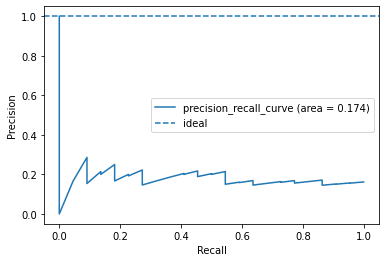

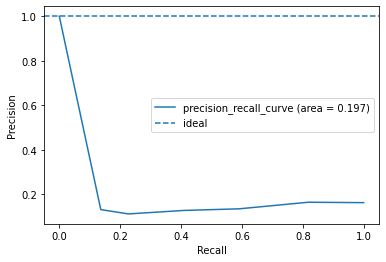

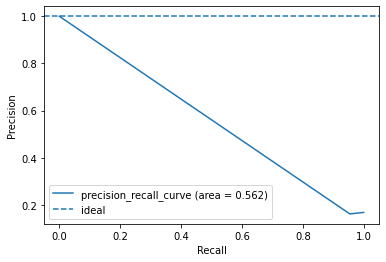

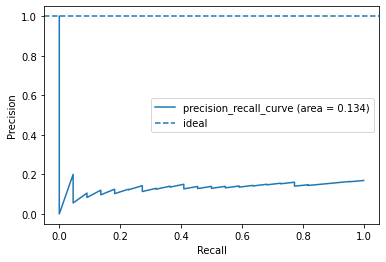

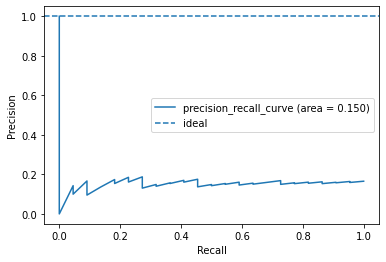

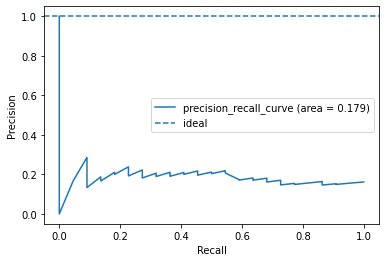

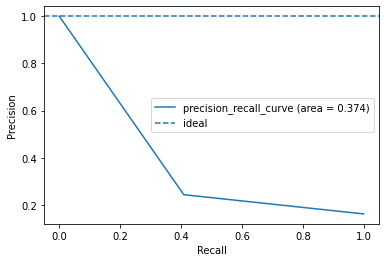

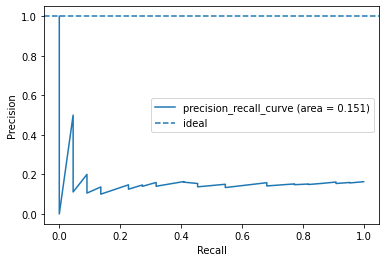

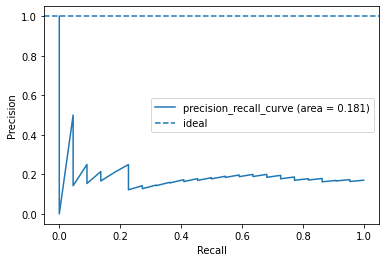

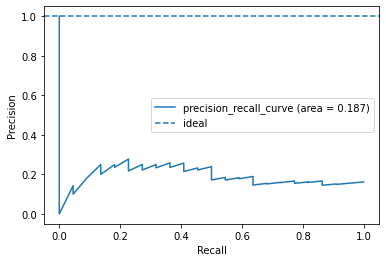

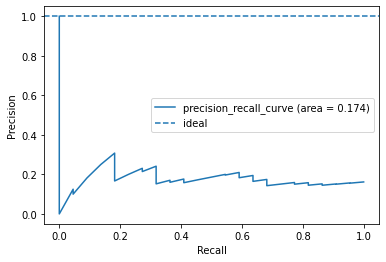

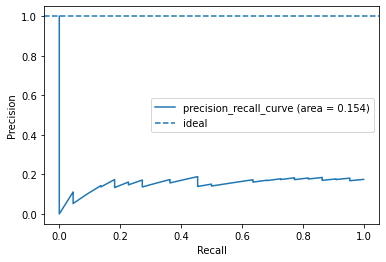

In [157]:
names = ["Logistic Regression", "Nearest Neighbors", 
         "Linear SVM", "Polynomial SVM", "RBF SVM", "Sigmoid SVM", 
         "Decision Tree","Random Forest", "AdaBoost", "Naive Bayes", 
         "Linear Discriminant Analysis","Quadratic Discriminant Analysis"]

classifiers = [
    LogisticRegression(),
    KNeighborsClassifier(),
    SVC(kernel="linear", probability=True, class_weight='balanced'),
    SVC(kernel="poly", probability=True, class_weight='balanced'),
    SVC(kernel="rbf", probability=True, class_weight='balanced'),
    SVC(kernel="sigmoid", probability=True, class_weight='balanced'),
    DecisionTreeClassifier(),
    RandomForestClassifier(class_weight='balanced'),
    AdaBoostClassifier(),
    GaussianNB(),
    LDA(),
    QDA()]

# PR曲線
for name, clf in zip(names, classifiers):
    clf.fit(X_train, y_train)
    # ある閾値の時の適合率、再現率の値を取得
    y_score = clf.predict_proba(X_validation)[:, 1] # 検証データがクラス1に属する確率
    precision, recall, threshold = precision_recall_curve(y_validation, y_score)

    # # 0から1まで0.05刻みで○をプロット
    # for i in range(21):
    #     close_point = np.argmin(np.abs(threshold - (i * 0.05)))
    #     plt.plot(recall[close_point], precision[close_point], 'o')

    plt.plot(recall, precision, label='precision_recall_curve (area = %0.3f)' % auc(recall, precision))
    plt.axhline(y=1.0, linestyle='--', label='ideal')
    plt.legend()
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.show()

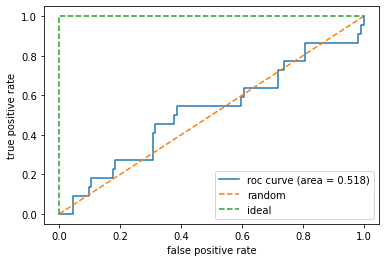

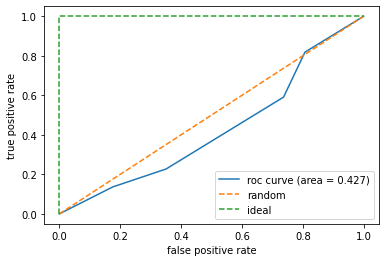

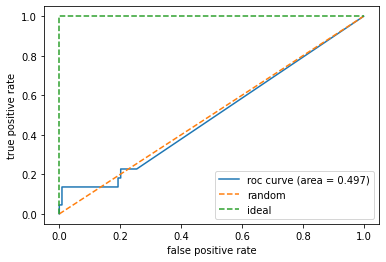

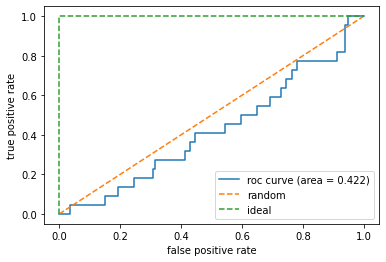

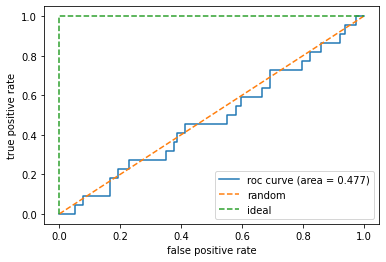

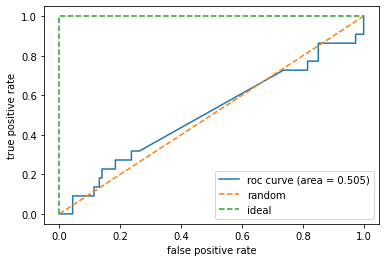

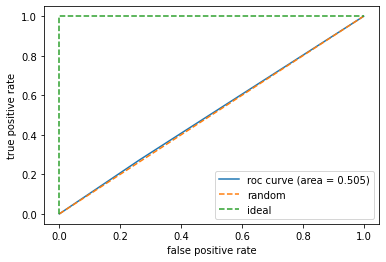

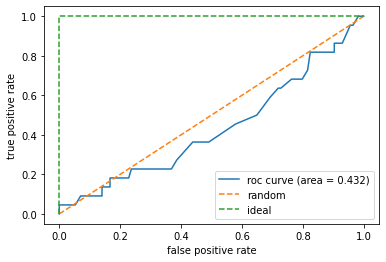

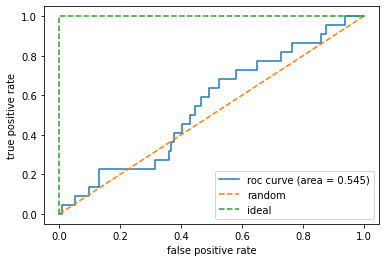

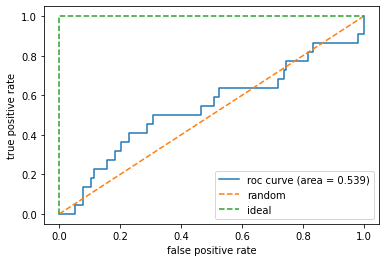

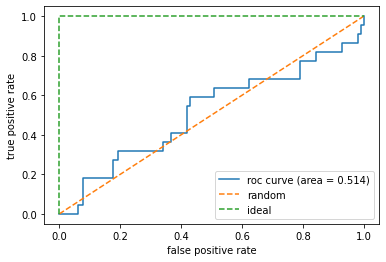

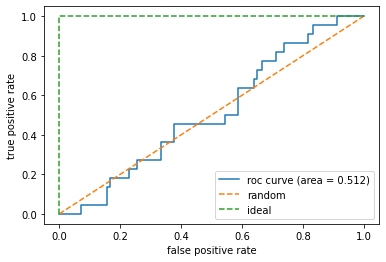

In [158]:
# ROC曲線の図示
for name, clf in zip(names, classifiers): 
    clf.fit(X_train, y_train)
    y_score = clf.predict_proba(X_validation)[:, 1] # 検証データがクラス1に属する確率
    fpr, tpr, thresholds = roc_curve(y_validation, y_score)

    plt.plot(fpr, tpr, label='roc curve (area = %0.3f)' % auc(fpr, tpr))
    plt.plot([0, 1], [0, 1], linestyle='--', label='random')
    plt.plot([0, 0, 1], [0, 1, 1], linestyle='--', label='ideal')
    plt.legend()
    plt.xlabel('false positive rate')
    plt.ylabel('true positive rate')
    plt.show()